# Feature Engineering Pipeline Assignment

## STEP 01. 데이터 준비

In [2]:
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler

sns.set_theme(style="whitegrid", font="DejaVu Sans")

RANDOM_STATE = 42
OUTPUT_DIR = Path("fair_assignment_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
raw = sm.datasets.fair.load_pandas().data.copy()
raw["had_affair"] = (raw["affairs"] > 0).astype(int)

column_description = pd.DataFrame(
    [
        ["rate_marriage", "categorical", "Self-rated marriage quality, 1 very poor to 5 very good"],
        ["age", "numeric", "Respondent age"],
        ["yrs_married", "numeric", "Years married"],
        ["children", "numeric", "Number of children"],
        ["religious", "categorical", "Religious level, 1 not religious to 4 strongly religious"],
        ["educ", "categorical", "Education level"],
        ["occupation", "categorical", "Respondent occupation group"],
        ["occupation_husb", "categorical", "Husband occupation group"],
        ["affairs", "numeric", "Measured time spent in extramarital affairs"],
        ["had_affair", "target", "Classification target: 1 if affairs > 0 else 0"],
    ],
    columns=["column", "type", "description"],
)

print("데이터 shape:", raw.shape)
display(raw.head())
display(column_description)
display(raw.info())

column_description.to_csv(TABLE_DIR / "column_description.csv", index=False)
pd.DataFrame({"rows": [raw.shape[0]], "columns": [raw.shape[1]]}).to_csv(TABLE_DIR / "dataset_shape.csv", index=False)

데이터 shape: (6366, 10)


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,had_affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1


,column,type,description
0,rate_marriage,categorical,"Self-rated marriage quality, 1 very poor to 5 ..."
1,age,numeric,Respondent age
2,yrs_married,numeric,Years married
3,children,numeric,Number of children
4,religious,categorical,"Religious level, 1 not religious to 4 strongly..."
5,educ,categorical,Education level
6,occupation,categorical,Respondent occupation group
7,occupation_husb,categorical,Husband occupation group
8,affairs,numeric,Measured time spent in extramarital affairs
9,had_affair,target,Classification target: 1 if affairs > 0 else 0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
 9   had_affair       6366 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 497.5 KB


None

## STEP 02. 탐색적 데이터 분석(EDA)

In [4]:
RATE_MARRIAGE = {1: "very_poor", 2: "poor", 3: "fair", 4: "good", 5: "very_good"}
RELIGIOUS = {1: "not_religious", 2: "mildly_religious", 3: "fairly_religious", 4: "strongly_religious"}
EDUC = {9: "grade_school", 12: "high_school", 14: "some_college", 16: "college_graduate", 17: "some_graduate_school", 20: "advanced_degree"}
OCCUPATION = {1: "student", 2: "farming_or_unskilled", 3: "white_collar", 4: "teacher_or_skilled", 5: "managerial_business", 6: "professional_advanced"}

def add_categorical_labels(df):
    labeled = df.copy()
    labeled["rate_marriage"] = labeled["rate_marriage"].astype(int).map(RATE_MARRIAGE)
    labeled["religious"] = labeled["religious"].astype(int).map(RELIGIOUS)
    labeled["educ"] = labeled["educ"].astype(int).map(EDUC)
    labeled["occupation"] = labeled["occupation"].astype(int).map(OCCUPATION)
    labeled["occupation_husb"] = labeled["occupation_husb"].astype(int).map(OCCUPATION)
    return labeled

def inject_missing_values(df):
    # 원본에는 결측치가 없어 결측치 처리 전략 비교를 위해 재현 가능한 결측치를 주입한다.
    rng = np.random.default_rng(RANDOM_STATE)
    missing_plan = {"age": 0.08, "yrs_married": 0.05, "children": 0.03, "occupation": 0.06, "religious": 0.04}
    missing_df = df.copy()
    for col, ratio in missing_plan.items():
        mask = rng.random(len(missing_df)) < ratio
        missing_df.loc[mask, col] = np.nan
    return missing_df

labeled = add_categorical_labels(raw)
df = inject_missing_values(labeled)

missing_ratio = (df.isna().mean().sort_values(ascending=False) * 100).reset_index()
missing_ratio.columns = ["column", "missing_ratio_percent"]
display(missing_ratio)
missing_ratio.to_csv(TABLE_DIR / "missing_ratio.csv", index=False)

,column,missing_ratio_percent
0,age,7.917059
1,occupation,6.220547
2,yrs_married,4.916745
3,religious,4.162740
4,children,3.220232
5,rate_marriage,0.000000
6,educ,0.000000
7,occupation_husb,0.000000
8,affairs,0.000000
9,had_affair,0.000000


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, int(count), lower, upper])

outlier_summary = pd.DataFrame(outlier_rows, columns=["column", "outlier_count", "iqr_lower", "iqr_upper"])
display(outlier_summary)
outlier_summary.to_csv(TABLE_DIR / "outlier_summary.csv", index=False)

,column,outlier_count,iqr_lower,iqr_upper
0,age,0,7.000000,47.000000
1,yrs_married,0,-18.500000,37.500000
2,children,198,-3.000000,5.000000
3,affairs,1049,-0.727273,1.212121
4,had_affair,0,-1.500000,2.500000


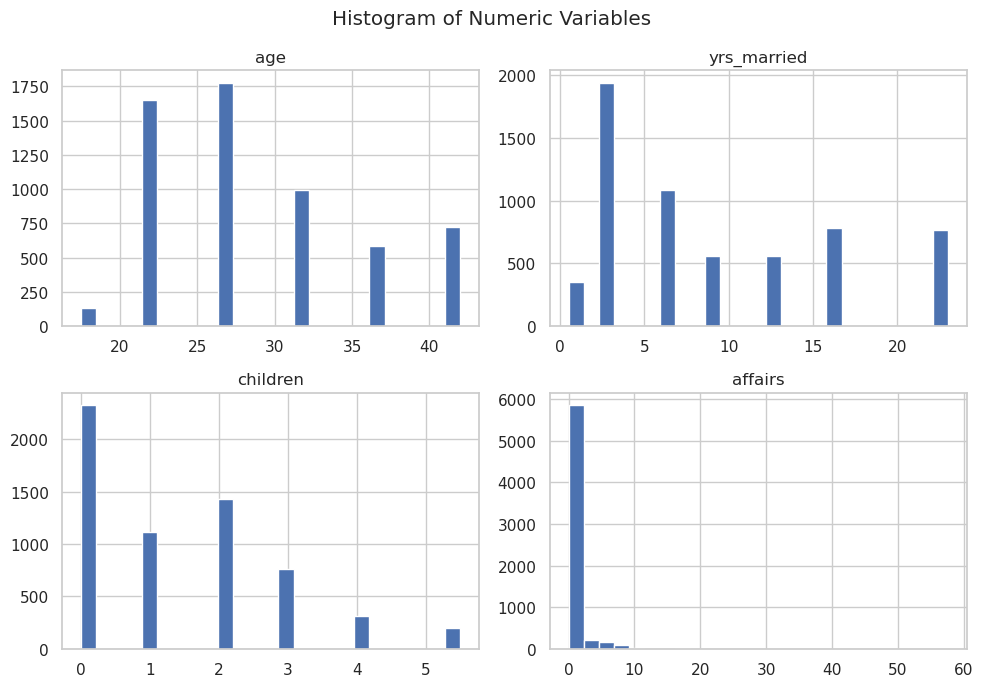

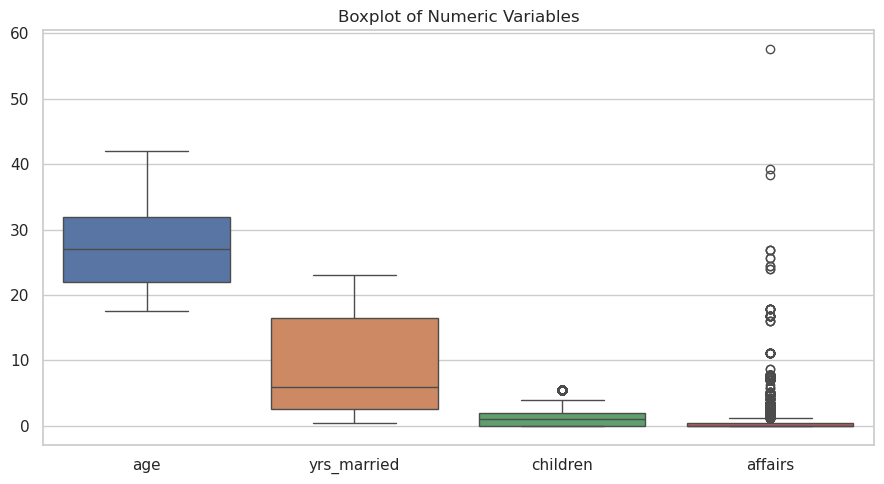

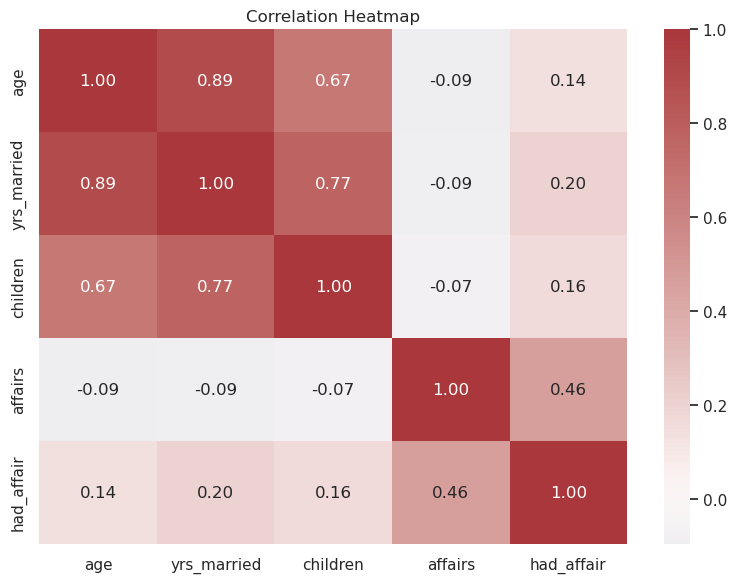

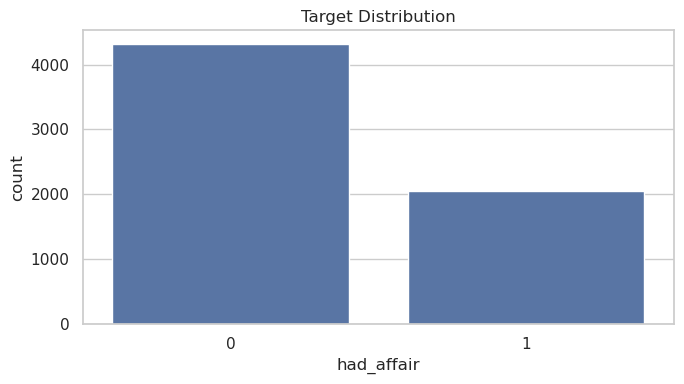

,had_affair,ratio
0,0,0.677505
1,1,0.322495


In [6]:
fig = df[["age", "yrs_married", "children", "affairs"]].hist(bins=25, figsize=(10, 7))
plt.suptitle("Histogram of Numeric Variables")
plt.tight_layout()
plt.savefig(FIG_DIR / "histogram_numeric_distribution.png", dpi=160)
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df[["age", "yrs_married", "children", "affairs"]])
plt.title("Boxplot of Numeric Variables")
plt.tight_layout()
plt.savefig(FIG_DIR / "boxplot_numeric_outliers.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_correlation.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="had_affair")
plt.title("Target Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "countplot_target_distribution.png", dpi=160)
plt.show()

target_distribution = df["had_affair"].value_counts(normalize=True).rename("ratio").reset_index()
target_distribution.columns = ["had_affair", "ratio"]
display(target_distribution)
target_distribution.to_csv(TABLE_DIR / "target_distribution.csv", index=False)

## STEP 03. 특성 공학 파이프라인 구현

In [7]:
def create_features(data):
    engineered = data.copy()
    engineered["age_group"] = pd.cut(
        engineered["age"],
        bins=[0, 25, 35, 45, 100],
        labels=["under_25", "25_34", "35_44", "45_plus"],
    ).astype("object")
    engineered["marriage_year_group"] = pd.cut(
        engineered["yrs_married"],
        bins=[-0.1, 3, 7, 15, 60],
        labels=["newly_married", "mid_married", "long_married", "very_long_married"],
    ).astype("object")
    engineered["children_per_married_year"] = engineered["children"] / (engineered["yrs_married"] + 1)
    engineered["married_age_ratio"] = engineered["yrs_married"] / engineered["age"]
    return engineered

engineered = create_features(df)
display(engineered[["age", "age_group", "yrs_married", "marriage_year_group", "children_per_married_year", "married_age_ratio"]].head())

,age,age_group,yrs_married,marriage_year_group,children_per_married_year,married_age_ratio
0,32.0,25_34,9.0,long_married,0.300000,0.281250
1,27.0,25_34,13.0,long_married,0.214286,0.481481
2,22.0,under_25,2.5,newly_married,0.000000,0.113636
3,37.0,35_44,16.5,very_long_married,0.228571,0.445946
4,27.0,25_34,9.0,long_married,0.100000,0.333333


In [8]:
def split_columns(data):
    target = "had_affair"
    X = data.drop(columns=["affairs", target])
    y = data[target]
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]
    return X, y, numeric_features, categorical_features

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(numeric_features, categorical_features, imputation, encoding, scaling):
    if imputation == "mean":
        numeric_imputer = SimpleImputer(strategy="mean")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    elif imputation == "median":
        numeric_imputer = SimpleImputer(strategy="median")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    elif imputation == "most_frequent":
        numeric_imputer = SimpleImputer(strategy="most_frequent")
        categorical_imputer = SimpleImputer(strategy="most_frequent")
    else:
        raise ValueError(imputation)

    scaler_map = {"standard": StandardScaler(), "minmax": MinMaxScaler(), "robust": RobustScaler(), "none": "passthrough"}
    encoder_map = {"onehot": make_onehot_encoder(), "label": OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), "none": "passthrough"}

    numeric_pipe = Pipeline([("imputer", numeric_imputer), ("scaler", scaler_map[scaling])])
    categorical_pipe = Pipeline([("imputer", categorical_imputer), ("encoder", encoder_map[encoding])])

    return ColumnTransformer(
        [("num", numeric_pipe, numeric_features), ("cat", categorical_pipe, categorical_features)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def make_pipeline(numeric_features, categorical_features, config, model):
    steps = [
        ("preprocess", make_preprocessor(numeric_features, categorical_features, config["imputation"], config["encoding"], config["scaling"]))
    ]
    if config["feature_selection"]:
        steps.append(("select", SelectKBest(score_func=f_classif, k=config["top_k"])))
    steps.append(("model", model))
    return Pipeline(steps)

## STEP 04. 변수 선택(Feature Selection)

## STEP 05. 모델 학습 및 평가

In [9]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test, experiment):
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else pred
    return {
        "experiment": experiment,
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "n_train": len(X_train),
        "n_test": len(X_test),
    }, pipeline

def run_base_experiment(raw_data):
    base = create_features(raw_data.copy()).dropna()
    X = base.drop(columns=["affairs", "had_affair"]).select_dtypes(include=[np.number])
    y = base["had_affair"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1),
    }
    rows = []
    for model_name, model in models.items():
        result, _ = evaluate_model(model_name, Pipeline([("model", model)]), X_train, X_test, y_train, y_test, "Base")
        rows.append(result)
    return rows

configs = {
    "Exp-1": {"imputation": "mean", "encoding": "onehot", "scaling": "standard", "feature_selection": False, "top_k": "all"},
    "Exp-2": {"imputation": "median", "encoding": "label", "scaling": "minmax", "feature_selection": True, "top_k": 10},
    "Exp-3": {"imputation": "most_frequent", "encoding": "onehot", "scaling": "robust", "feature_selection": True, "top_k": 10},
}
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1),
}

X, y, numeric_features, categorical_features = split_columns(engineered)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

rows = run_base_experiment(raw)
fitted = {}
for exp_name, config in configs.items():
    for model_name, model in models.items():
        pipe = make_pipeline(numeric_features, categorical_features, config, model)
        result, fitted_pipe = evaluate_model(model_name, pipe, X_train, X_test, y_train, y_test, exp_name)
        rows.append(result)
        fitted[(exp_name, model_name)] = fitted_pipe

results = pd.DataFrame(rows).sort_values(["experiment", "model"]).reset_index(drop=True)
display(results.round(4))
results.to_csv(TABLE_DIR / "model_performance_comparison.csv", index=False)

,experiment,model,accuracy,precision,recall,f1,roc_auc,n_train,n_test
0,Base,Logistic Regression,0.7072,0.5714,0.3698,0.4490,0.7302,5092,1274
1,Base,Random Forest,0.6672,0.4812,0.4039,0.4392,0.6666,5092,1274
2,Exp-1,Logistic Regression,0.7119,0.5827,0.3771,0.4579,0.7220,5092,1274
3,Exp-1,Random Forest,0.6672,0.4802,0.3844,0.4270,0.6770,5092,1274
4,Exp-2,Logistic Regression,0.6790,0.5054,0.2287,0.3149,0.6707,5092,1274
5,Exp-2,Random Forest,0.6829,0.5113,0.3844,0.4389,0.6671,5092,1274
6,Exp-3,Logistic Regression,0.7025,0.5734,0.3041,0.3975,0.7035,5092,1274
7,Exp-3,Random Forest,0.6821,0.5113,0.3309,0.4018,0.6747,5092,1274


In [10]:
experiment_plan = pd.DataFrame(
    [
        ["Base", "없음", "없음", "없음", "없음"],
        ["Exp-1", "Mean", "One-Hot", "StandardScaler", "X"],
        ["Exp-2", "Median", "Label/Ordinal", "MinMaxScaler", "O"],
        ["Exp-3", "Most Frequent", "One-Hot", "RobustScaler", "O"],
    ],
    columns=["실험", "결측치 처리", "인코딩", "스케일링", "Feature Selection"],
)
display(experiment_plan)
experiment_plan.to_csv(TABLE_DIR / "experiment_plan.csv", index=False)

,실험,결측치 처리,인코딩,스케일링,Feature Selection
0,Base,없음,없음,없음,없음
1,Exp-1,Mean,One-Hot,StandardScaler,X
2,Exp-2,Median,Label/Ordinal,MinMaxScaler,O
3,Exp-3,Most Frequent,One-Hot,RobustScaler,O


In [11]:
def get_feature_names(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        return np.array([f"feature_{i}" for i in range(preprocessor.transformers_[0][2].__len__())])

selection_rows = []
for (exp_name, model_name), pipe in fitted.items():
    if "select" not in pipe.named_steps:
        continue
    feature_names = get_feature_names(pipe.named_steps["preprocess"])
    selector = pipe.named_steps["select"]
    selected_names = set(feature_names[selector.get_support()])
    for feature, score in zip(feature_names, selector.scores_):
        selection_rows.append({"experiment": exp_name, "model": model_name, "feature": feature, "score": score, "selected": feature in selected_names})

feature_selection_scores = pd.DataFrame(selection_rows).sort_values(["experiment", "model", "score"], ascending=[True, True, False])
display(feature_selection_scores[feature_selection_scores["selected"]].head(30))
feature_selection_scores.to_csv(TABLE_DIR / "feature_selection_scores.csv", index=False)

,experiment,model,feature,score,selected
5,Exp-2,Logistic Regression,rate_marriage,249.727515,True
4,Exp-2,Logistic Regression,married_age_ratio,247.990871,True
1,Exp-2,Logistic Regression,yrs_married,205.188281,True
2,Exp-2,Logistic Regression,children,128.626935,True
0,Exp-2,Logistic Regression,age,84.913798,True
10,Exp-2,Logistic Regression,age_group,51.766449,True
3,Exp-2,Logistic Regression,children_per_married_year,28.120071,True
7,Exp-2,Logistic Regression,educ,21.067310,True
11,Exp-2,Logistic Regression,marriage_year_group,4.778221,True
8,Exp-2,Logistic Regression,occupation,0.903541,True


,feature,importance
2,children,0.237015
6,rate_marriage_very_good,0.173246
3,married_age_ratio,0.139617
4,rate_marriage_fair,0.110660
1,yrs_married,0.110314
0,age,0.085259
5,rate_marriage_poor,0.070177
8,marriage_year_group_newly_married,0.054575
9,marriage_year_group_very_long_married,0.010748
7,age_group_under_25,0.008388


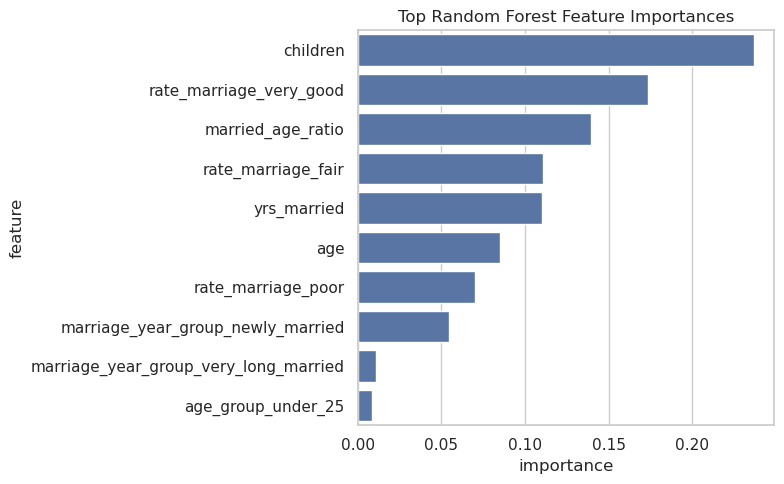

In [12]:
best_rf_pipe = fitted[("Exp-3", "Random Forest")]
feature_names = get_feature_names(best_rf_pipe.named_steps["preprocess"])
if "select" in best_rf_pipe.named_steps:
    feature_names = feature_names[best_rf_pipe.named_steps["select"].get_support()]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf_pipe.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df.head(12))
importance_df.to_csv(TABLE_DIR / "random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(12), x="importance", y="feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(FIG_DIR / "random_forest_feature_importance.png", dpi=160)
plt.show()

## 추가 실험. GridSearchCV

In [13]:
grid_config = {"imputation": "most_frequent", "encoding": "onehot", "scaling": "robust", "feature_selection": True, "top_k": 10}
grid_pipe = make_pipeline(
    numeric_features,
    categorical_features,
    grid_config,
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
)

grid = GridSearchCV(
    grid_pipe,
    param_grid={
        "model__n_estimators": [150, 250],
        "model__max_depth": [4, 8, None],
        "model__min_samples_leaf": [1, 3],
    },
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
)
grid.fit(X_train, y_train)
grid_pred = grid.predict(X_test)
grid_proba = grid.predict_proba(X_test)[:, 1]

grid_result = pd.DataFrame([{
    "best_params": str(grid.best_params_),
    "cv_best_roc_auc": grid.best_score_,
    "test_accuracy": accuracy_score(y_test, grid_pred),
    "test_f1": f1_score(y_test, grid_pred, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, grid_proba),
}])

display(grid_result)
grid_result.to_csv(TABLE_DIR / "grid_search_result.csv", index=False)

,best_params,cv_best_roc_auc,test_accuracy,test_f1,test_roc_auc
0,"{'model__max_depth': 8, 'model__min_samples_le...",0.733646,0.696232,0.40553,0.698749
